<a href="https://colab.research.google.com/github/write2chrischacko/Healthcare-Appointment-No-Show-Analysis-and-Prediction/blob/main/Healthcare_NO_SHOW_DESCRIPTIVE_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA CLEANING**

In [31]:
import pandas as pd
import numpy as np

In [32]:
df = pd.read_csv('/content/MedicalAppointment.csv')
display(df.head(10))

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


In [33]:
df.columns = df.columns.str.upper().str.replace('-', '_').str.replace(' ', '_').str.replace('id$', '_id', regex=True)
display(df.columns)

Index(['PATIENTID', 'APPOINTMENTID', 'GENDER', 'SCHEDULEDDAY',
       'APPOINTMENTDAY', 'AGE', 'NEIGHBOURHOOD', 'SCHOLARSHIP', 'HIPERTENSION',
       'DIABETES', 'ALCOHOLISM', 'HANDCAP', 'SMS_RECEIVED', 'NO_SHOW'],
      dtype='object')

In [34]:
df = df.rename(columns={'HIPERTENSION': 'HYPERTENSION'})
df = df.rename(columns={'SCHEDULEDDAY':'SCHEDULED_DAY'})
df = df.rename(columns={'APPOINTMENTDAY':'APPOINTMENT_DAY'})
df = df.rename(columns={'SCHEDULEDTIME':'SCHEDULED_TIME'})
df = df.rename(columns={'HANDCAP':'HANDICAP'})
df = df.rename(columns={'PATIENTID': 'PATIENT_ID', 'APPOINTMENTID': 'APPOINTMENT_ID'})
display(df.columns)

Index(['PATIENT_ID', 'APPOINTMENT_ID', 'GENDER', 'SCHEDULED_DAY',
       'APPOINTMENT_DAY', 'AGE', 'NEIGHBOURHOOD', 'SCHOLARSHIP',
       'HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP', 'SMS_RECEIVED',
       'NO_SHOW'],
      dtype='object')

In [35]:
print("Renamed columns:", list(df.columns), "\n")


Renamed columns: ['PATIENT_ID', 'APPOINTMENT_ID', 'GENDER', 'SCHEDULED_DAY', 'APPOINTMENT_DAY', 'AGE', 'NEIGHBOURHOOD', 'SCHOLARSHIP', 'HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP', 'SMS_RECEIVED', 'NO_SHOW'] 



In [36]:
missing_values = df.isnull().sum()
display(missing_values)

,0
PATIENT_ID,0
APPOINTMENT_ID,0
GENDER,0
SCHEDULED_DAY,0
APPOINTMENT_DAY,0
AGE,0
NEIGHBOURHOOD,0
SCHOLARSHIP,0
HYPERTENSION,0
DIABETES,0


In [37]:
null_counts = df.isnull().sum()
print(null_counts)
print(f"\n✓ Total nulls: {null_counts.sum()} — no imputation needed.\n")

PATIENT_ID         0
APPOINTMENT_ID     0
GENDER             0
SCHEDULED_DAY      0
APPOINTMENT_DAY    0
AGE                0
NEIGHBOURHOOD      0
SCHOLARSHIP        0
HYPERTENSION       0
DIABETES           0
ALCOHOLISM         0
HANDICAP           0
SMS_RECEIVED       0
NO_SHOW            0
dtype: int64

✓ Total nulls: 0 — no imputation needed.



In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PATIENT_ID       110527 non-null  float64
 1   APPOINTMENT_ID   110527 non-null  int64  
 2   GENDER           110527 non-null  object 
 3   SCHEDULED_DAY    110527 non-null  object 
 4   APPOINTMENT_DAY  110527 non-null  object 
 5   AGE              110527 non-null  int64  
 6   NEIGHBOURHOOD    110527 non-null  object 
 7   SCHOLARSHIP      110527 non-null  int64  
 8   HYPERTENSION     110527 non-null  int64  
 9   DIABETES         110527 non-null  int64  
 10  ALCOHOLISM       110527 non-null  int64  
 11  HANDICAP         110527 non-null  int64  
 12  SMS_RECEIVED     110527 non-null  int64  
 13  NO_SHOW          110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [39]:
# Dates → datetime (UTC, then strip timezone for simplicity)
df["SCHEDULED_DAY"]   = pd.to_datetime(df["SCHEDULED_DAY"],   utc=True).dt.tz_localize(None)
df["APPOINTMENT_DAY"] = pd.to_datetime(df["APPOINTMENT_DAY"], utc=True).dt.tz_localize(None)
df["PATIENT_ID"]     = df["PATIENT_ID"].astype(str)
df["APPOINTMENT_ID"] = df["APPOINTMENT_ID"].astype(str)
df["NO_SHOW"] = (df["NO_SHOW"] == "Yes").astype(int)
df["NEIGHBOURHOOD"] = df["NEIGHBOURHOOD"].str.strip().str.title()
print("Updated dtypes:")
print(df.dtypes, "\n")

Updated dtypes:
PATIENT_ID                 object
APPOINTMENT_ID             object
GENDER                     object
SCHEDULED_DAY      datetime64[ns]
APPOINTMENT_DAY    datetime64[ns]
AGE                         int64
NEIGHBOURHOOD              object
SCHOLARSHIP                 int64
HYPERTENSION                int64
DIABETES                    int64
ALCOHOLISM                  int64
HANDICAP                    int64
SMS_RECEIVED                int64
NO_SHOW                     int64
dtype: object 



In [40]:
original_len = len(df)

# Negative age
invalid_age = df["AGE"] < 0
print(f"  Rows with negative age   : {invalid_age.sum()}")
df = df[~invalid_age]

# Age outliers
extreme_age = df["AGE"] > 115
print(f"  Rows with age > 115  : {extreme_age.sum()}")
df = df[~extreme_age]


  Rows with negative age   : 1
  Rows with age > 115  : 0


In [41]:
# Appointment scheduled AFTER the appointment day (scheduling error)
scheduling_error = df["SCHEDULED_DAY"].dt.date > df["APPOINTMENT_DAY"].dt.date
print(f"  Scheduling errors : {scheduling_error.sum()}")
df = df[~scheduling_error]

  Scheduling errors : 5


In [42]:
# Duplicate Appointment_IDs
dup_appt = df["APPOINTMENT_ID"].duplicated()
print(f"  Duplicate appointment IDs: {dup_appt.sum()}")
df = df[~dup_appt]


  Duplicate appointment IDs: 0


In [43]:
removed = original_len - len(df)
print(f"\n  Rows removed : {removed:,}")
print(f"  Rows remaining: {len(df):,}\n")


  Rows removed : 6
  Rows remaining: 110,521



In [44]:
# Day of week for the appointment (0=Mon … 6=Sun)
df["appointment_weekday"]      = df["APPOINTMENT_DAY"].dt.dayofweek
df["appointment_weekday_name"] = df["APPOINTMENT_DAY"].dt.day_name()

In [45]:
# Create 'repeat_no_show' column: 1 if patient has ever no-showed, 0 otherwise
df['repeat_no_show'] = df.groupby('PATIENT_ID')['NO_SHOW'].transform('max')

In [46]:
import pandas as pd

day_map = pd.DataFrame({
    "Number": range(7),
    "Day"   : ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
})

print(day_map.to_string(index=False))

 Number       Day
      0    Monday
      1   Tuesday
      2 Wednesday
      3  Thursday
      4    Friday
      5  Saturday
      6    Sunday


In [47]:
print(df[["APPOINTMENT_DAY", "appointment_weekday", "appointment_weekday_name"]].head(50))

   APPOINTMENT_DAY  appointment_weekday appointment_weekday_name
0       2016-04-29                    4                   Friday
1       2016-04-29                    4                   Friday
2       2016-04-29                    4                   Friday
3       2016-04-29                    4                   Friday
4       2016-04-29                    4                   Friday
5       2016-04-29                    4                   Friday
6       2016-04-29                    4                   Friday
7       2016-04-29                    4                   Friday
8       2016-04-29                    4                   Friday
9       2016-04-29                    4                   Friday
10      2016-04-29                    4                   Friday
11      2016-04-29                    4                   Friday
12      2016-04-29                    4                   Friday
13      2016-04-29                    4                   Friday
14      2016-04-29       

**DESCRIPTIVE** **STATISTICS**

In [48]:
no_show_percentage = df['NO_SHOW'].mean() * 100
print(f"Percentage of patients who did not show up: {no_show_percentage:.2f}%")

Percentage of patients who did not show up: 20.19%


In [62]:
# OVERALL SUMMARY
total        = len(df)
noshow_rate  = (df['NO_SHOW'] == 1).mean() * 100
avg_age      = df[df['AGE'] >= 0]['AGE'].mean()
avg_wait     = df[df['waiting_days'] >= 0]['waiting_days'].mean()
female_pct   = (df['GENDER'] == 'F').mean() * 100

print(f"  Total appointments   : {total:,}")
print(f"  No-show rate         : {noshow_rate:.1f}%")
print(f"  Average patient age  : {avg_age:.1f} years")
print(f"  Average wait days    : {avg_wait:.1f} days")
print(f"  Female patients      : {female_pct:.1f}%")
print(f"  Missing values       : 0")
print(f"\n  Key findings:")
print(f"  • Patients aged 11-30 have the highest no-show rate (~25%)")
print(f"  • SMS receivers show MORE no-shows (27.6% vs 16.7%)")
print(f"  • Hypertension/Diabetes patients attend more reliably")
print(f"  • Saturday has highest no-show rate; Thursday the lowest")
print(f"  • Longer wait time is strongly linked to more no-shows")

  Total appointments   : 110,521
  No-show rate         : 20.2%
  Average patient age  : 37.1 years
  Average wait days    : 14.6 days
  Female patients      : 65.0%
  Missing values       : 0

  Key findings:
  • Patients aged 11-30 have the highest no-show rate (~25%)
  • SMS receivers show MORE no-shows (27.6% vs 16.7%)
  • Hypertension/Diabetes patients attend more reliably
  • Saturday has highest no-show rate; Thursday the lowest
  • Longer wait time is strongly linked to more no-shows


In [49]:
# SUMMARY OF TOTAL PATIENTS AND HOW MANY HAVE FINANCIAL AID, DISEASES AND DISABILITIES
total = len(df)

print(f"\nTotal Patients : {total:,}")

print(f"\n--- Financial ---")
print(f"Scholarship      : {df['SCHOLARSHIP'].sum():,} ({df['SCHOLARSHIP'].mean()*100:.1f}%)")

print(f"\n--- Disability ---")
print(f"Handicap         : {df['HANDICAP'].sum():,} ({df['HANDICAP'].mean()*100:.1f}%)")

print(f"\n--- Medical Conditions ---")
print(f"Hypertension     : {df['HYPERTENSION'].sum():,} ({df['HYPERTENSION'].mean()*100:.1f}%)")
print(f"Diabetes         : {df['DIABETES'].sum():,} ({df['DIABETES'].mean()*100:.1f}%)")
print(f"Alcoholism       : {df['ALCOHOLISM'].sum():,} ({df['ALCOHOLISM'].mean()*100:.1f}%)")

print(f"\n--- Communication ---")
print(f"SMS Received     : {df['SMS_RECEIVED'].sum():,} ({df['SMS_RECEIVED'].mean()*100:.1f}%)")


Total Patients : 110,521

--- Financial ---
Scholarship      : 10,861 (9.8%)

--- Disability ---
Handicap         : 2,457 (2.2%)

--- Medical Conditions ---
Hypertension     : 21,801 (19.7%)
Diabetes         : 7,943 (7.2%)
Alcoholism       : 3,360 (3.0%)

--- Communication ---
SMS Received     : 35,482 (32.1%)


In [50]:
# OVERALL DATASET SUMMARY
df['waiting_days'] = (df['APPOINTMENT_DAY'] - df['SCHEDULED_DAY']).dt.days

print("=" * 40)
print("Overall Dataset Summary")
print("=" * 40)
print(f"  {'Shape':<20} : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  {'No-show rate':<20} : {df['NO_SHOW'].mean()*100:.2f}%")
print(f"  {'Date range':<20} : {df['APPOINTMENT_DAY'].min().date()} → {df['APPOINTMENT_DAY'].max().date()}")
print(f"  {'Unique patients':<20} : {df['PATIENT_ID'].nunique():,}")
print(f"  {'Neighbourhoods':<20} : {df['NEIGHBOURHOOD'].nunique()}")
print(f"  {'Avg waiting days':<20} : {df[df['waiting_days'] >= 0]['waiting_days'].mean():.1f} days")

print("\n" + "=" * 40)
print("Descriptive Statistics for All Columns")
print("=" * 40)
print(df.describe(include="all").T[["count", "unique", "top", "freq", "mean", "min", "max"]].to_string())

Overall Dataset Summary
  Shape                : 110,521 rows x 18 columns
  No-show rate         : 20.19%
  Date range           : 2016-04-29 → 2016-06-08
  Unique patients      : 62,298
  Neighbourhoods       : 81
  Avg waiting days     : 14.6 days

Descriptive Statistics for All Columns
                             count  unique                top   freq                           mean                  min                  max
PATIENT_ID                  110521   62298  822145925426128.0     88                            NaN                  NaN                  NaN
APPOINTMENT_ID              110521  110521            5629448      1                            NaN                  NaN                  NaN
GENDER                      110521       2                  F  71836                            NaN                  NaN                  NaN
SCHEDULED_DAY               110521     NaN                NaN    NaN  2016-05-09 07:48:50.890228992  2015-11-10 07:13:56  2016-06-08 20:07:23

In [117]:
# Create waiting_days groups
wait_bins = [-10, 0, 7, 14, 30, 60, df['waiting_days'].max() + 1]
wait_labels = ['Same day', '1-7d', '8-14d', '15-30d', '31-60d', '60+d']
df['WAIT_GROUP'] = pd.cut(df['waiting_days'], bins=wait_bins, labels=wait_labels, right=False)

In [55]:
# DESCRIPTIVE STATISTICS FOR SPECIFIC COLUMS
print(df[['AGE', 'waiting_days', 'SCHOLARSHIP', 'HYPERTENSION',
          'DIABETES', 'ALCOHOLISM', 'HANDICAP', 'SMS_RECEIVED']].describe().round(2))

             AGE  waiting_days  SCHOLARSHIP  HYPERTENSION   DIABETES  \
count  110521.00     110521.00     110521.0      110521.0  110521.00   
mean       37.09          9.18          0.1           0.2       0.07   
std        23.11         15.26          0.3           0.4       0.26   
min         0.00         -1.00          0.0           0.0       0.00   
25%        18.00         -1.00          0.0           0.0       0.00   
50%        37.00          3.00          0.0           0.0       0.00   
75%        55.00         14.00          0.0           0.0       0.00   
max       115.00        178.00          1.0           1.0       1.00   

       ALCOHOLISM   HANDICAP  SMS_RECEIVED  
count   110521.00  110521.00     110521.00  
mean         0.03       0.02          0.32  
std          0.17       0.16          0.47  
min          0.00       0.00          0.00  
25%          0.00       0.00          0.00  
50%          0.00       0.00          0.00  
75%          0.00       0.00        

In [51]:
# NO-SHOW RATE BY EACH CATEGORY

# AGE GROUP
print("\n" + "=" * 40)
print("NO-SHOW RATE BY AGE GROUP")
print("=" * 40)

# Define age bins and labels
age_bins = [0, 18, 35, 60, 100]
age_labels = ['0-17', '18-34', '35-59', '60+']
df['age_group'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

age = df.groupby('age_group', observed=True)['NO_SHOW'].mean() * 100
age = age.sort_values(ascending=False);
for group, rate in age.items():
    print(f"{group:25s} : {rate:.1f}%")

# GENDER
print("\n" + "=" * 40)
print("NO-SHOW RATE BY GENDER")
print("=" * 40)
gender = df.groupby("GENDER")["NO_SHOW"].mean() * 100
for g, rate in gender.items():
    print(f"{g} : {rate:.1f}%")

# MEDICAL CONDITIONS
print("\n" + "=" * 40)
print("NO-SHOW RATE BY MEDICAL CONDITION")
print("=" * 40)
for col in ["HYPERTENSION", "DIABETES", "ALCOHOLISM", "HANDICAP"]:
    yes = df[df[col] == 1]["NO_SHOW"].mean() * 100
    no  = df[df[col] == 0]["NO_SHOW"].mean() * 100
    print(f"{col:15s} → has it: {yes:.1f}%   does not: {no:.1f}%")

# REPEAT NO-SHOW
print("\n" + "=" * 40)
print("REPEAT NO-SHOW BEHAVIOUR")
print("=" * 40)
df['repeat_no_show'] = df.groupby('PATIENT_ID')['NO_SHOW'].transform('max')
repeat = df.groupby("repeat_no_show")["NO_SHOW"].mean() * 100
print(f"First-time / occasional : {repeat[0]:.1f}%")
print(f"Repeat no-show patients : {repeat[1]:.1f}%")

# OVERALL
print("=" * 40)
print("OVERALL")
print("=" * 40)
total      = len(df)
no_shows   = df["NO_SHOW"].sum()
shows      = total - no_shows
rate       = df["NO_SHOW"].mean() * 100
print(f"Total appointments : {total:,}")
print(f"No-shows           : {no_shows:,}")
print(f"Showed up          : {shows:,}")
print(f"No-show rate       : {rate:.1f}%")


NO-SHOW RATE BY AGE GROUP
18-34                     : 24.0%
0-17                      : 21.9%
35-59                     : 19.3%
60+                       : 15.3%

NO-SHOW RATE BY GENDER
F : 20.3%
M : 20.0%

NO-SHOW RATE BY MEDICAL CONDITION
HYPERTENSION    → has it: 17.3%   does not: 20.9%
DIABETES        → has it: 18.0%   does not: 20.4%
ALCOHOLISM      → has it: 20.1%   does not: 20.2%
HANDICAP        → has it: 17.8%   does not: 20.2%

REPEAT NO-SHOW BEHAVIOUR
First-time / occasional : 0.0%
Repeat no-show patients : 51.9%
OVERALL
Total appointments : 110,521
No-shows           : 22,314
Showed up          : 88,207
No-show rate       : 20.2%


**Overall Dataset Summary:**

Shape: The dataset contains 110,521 rows and 19 columns.

No-show rate: Approximately 20.19% of appointments are no-shows.

Date range: Appointments span from April 29, 2016, to June 08, 2016.

Unique patients: There are 62,298 unique patients.

Neighbourhoods: Appointments are recorded across 81 different neighborhoods.

Average waiting days: On average, patients wait 14.6 days between scheduling and their appointment.

**Descriptive Statistics for All Columns:** This section provides statistics like count, number of unique values, most frequent value (top), and its frequency (freq) for categorical columns. For numerical columns, it includes mean, minimum, and maximum values. Some key observations from the detailed statistics include:

PATIENT_ID and APPOINTMENT_ID are largely unique identifiers.

GENDER: 'F' (Female) is the most frequent gender, with 71,836 occurrences.

SCHEDULED_DAY and APPOINTMENT_DAY: These are date/time columns with a range from 2015-11-10 to 2016-06-08.

AGE: Ages range from 0 to 115 years, with an average of approximately 37 years.

NEIGHBOURHOOD: 'Jardim Camburi' is the most frequent neighborhood with 7,717 appointments.

SCHOLARSHIP, HYPERTENSION, DIABETES, ALCOHOLISM, SMS_RECEIVED, NO_SHOW: These are binary (0/1) columns, and their means represent the proportion of '1's (e.g., 9.8% received a scholarship, 20.2% were no-shows).

Handicap: Values range from 0 to 4, with a mean of 0.022.

appointment_weekday: Represents the day of the week (0-5), with an average of 1.86 (Tuesday/Wednesday).

appointment_weekday_name: 'Wednesday' is the most frequent appointment day.

age_group: '35-59' is the most frequent age group.

repeat_no_show: Mean of 0.389 suggests about 38.9% of appointments belong to patients who have previously no-showed.

waiting_days: Waiting times range from -1 (appointments scheduled on the same day or a day after the appointment, which is an error in data entry or same-day scheduling) to 178 days, with an average of 9.18 days.

SCHEDULED_DAY: This is the date and time when the patient made or booked their appointment. It's when the appointment was entered into the system.

APPOINTMENT_DAY: This is the date when the actual medical appointment is scheduled to take place. This is the day the patient is expected to show up at the clinic.

**VISUALIZATION**

In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [53]:
# colour palette
TEAL   = '#1D9E75'
PURPLE = '#7F77DD'
CORAL  = '#D85A30'
AMBER  = '#EF9F27'
BLUE   = '#378ADD'
RED    = '#E24B4A'
GRAY   = '#888780'
GREEN  = '#639922'

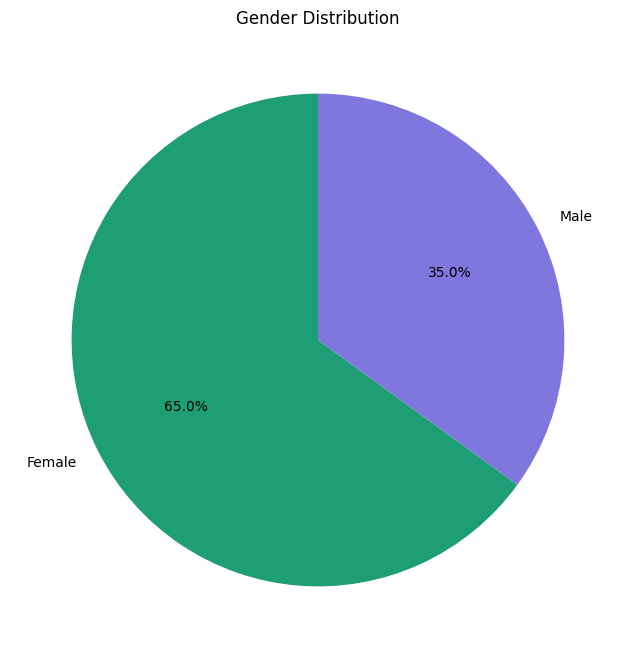

In [67]:
# Chart 1: Gender pie
# value_counts() counts F vs M, pie() draws a circle chart
fig, axes = plt.subplots(1, 1, figsize=(8, 8), squeeze=False) # Create a single subplot, ensure axes is an array
gender_counts = df['GENDER'].value_counts()
axes[0,0].pie(
    gender_counts,
    labels=['Female', 'Male'],
    colors=[TEAL, PURPLE],
    autopct='%1.1f%%',   # show % inside each slice
    startangle=90
)
axes[0,0].set_title('Gender Distribution')
plt.show()

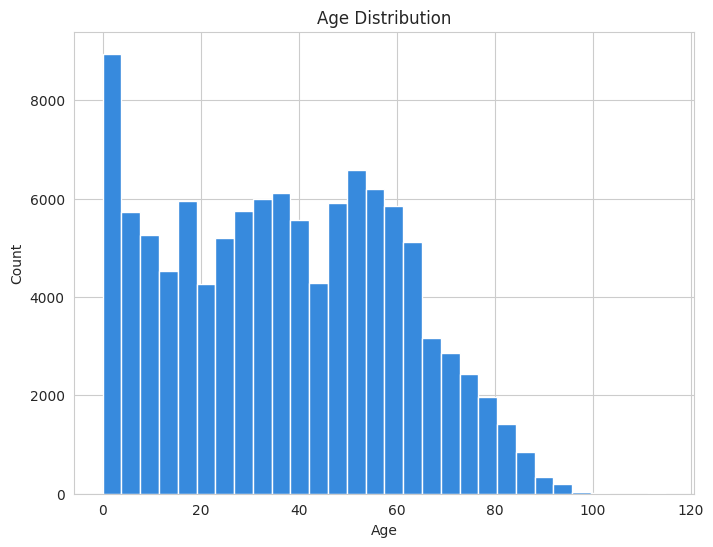

In [76]:
# Chart 2: Age histogram
# hist() divides AGE into 30 equal buckets and counts each
# Create a new figure and axes specifically for this histogram
fig_age, ax_age = plt.subplots(1, 1, figsize=(8, 6))
ax_age.hist(df[df['AGE'] >= 0]['AGE'], bins=30,
               color=BLUE, edgecolor='white')
ax_age.set_title('Age Distribution')
ax_age.set_xlabel('Age')
ax_age.set_ylabel('Count')
plt.show()

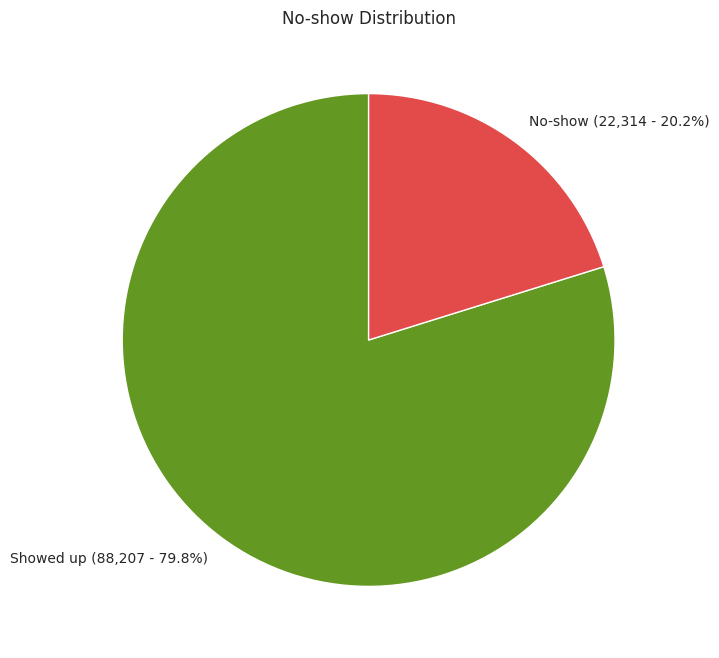

In [79]:
# Chart 3: No-show pie
# Create a new figure and axes for this pie chart
fig_ns, ax_ns = plt.subplots(1, 1, figsize=(8, 8))
ns_counts = df['NO_SHOW'].value_counts()

total_appointments = ns_counts.sum()

custom_labels = []
for index, count in ns_counts.items():
    category = 'Showed up' if index == 0 else 'No-show'
    percentage = (count / total_appointments) * 100
    custom_labels.append(f'{category} ({count:,} - {percentage:.1f}%)')

ax_ns.pie(
    ns_counts,
    labels=custom_labels,
    colors=[GREEN, RED],
    startangle=90
)
ax_ns.set_title('No-show Distribution')
plt.show()

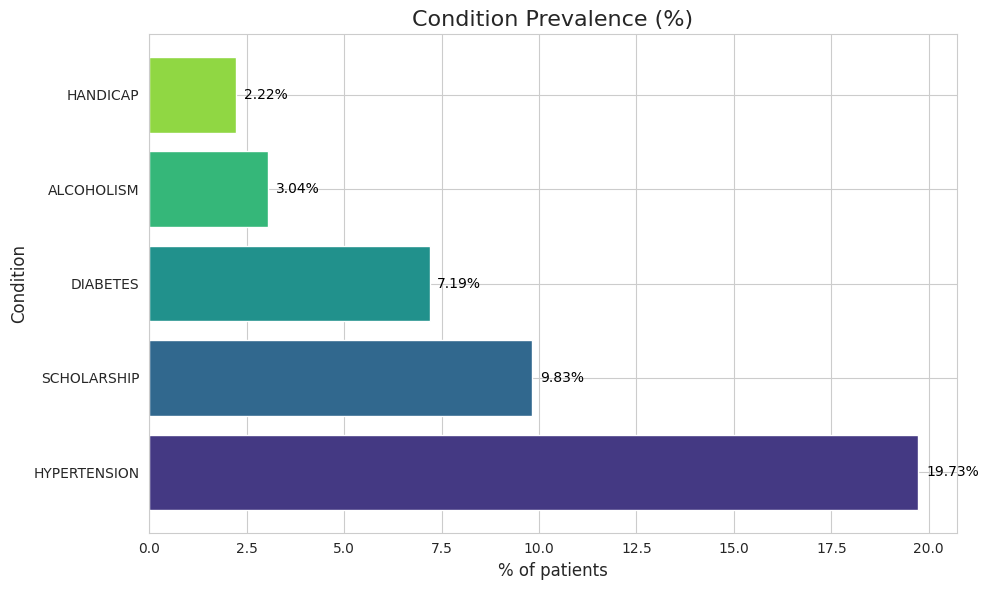

In [87]:
# Chart 4: Condition prevalence (horizontal bar)
# .mean()*100 on a 0/1 column gives the % of patients with it
conditions = ['HYPERTENSION', 'SCHOLARSHIP', 'DIABETES', 'ALCOHOLISM', 'HANDICAP']
prev = df[conditions].mean().mul(100).round(2).sort_values(ascending=False)

sns.set_style("whitegrid")

# Create a new figure and axes for this chart
fig_prev, ax_prev = plt.subplots(1, 1, figsize=(10, 6))

# Use a Seaborn color palette
colors = sns.color_palette('viridis', len(prev.index))
ax_prev.barh(prev.index, prev.values,
               color=colors)
ax_prev.set_title('Condition Prevalence (%)', fontsize=16)
ax_prev.set_xlabel('% of patients', fontsize=12)
ax_prev.set_ylabel('Condition', fontsize=12) # Add y-axis label

# Add value labels at end of each bar
for i, v in enumerate(prev.values):
    ax_prev.text(v + 0.2, i, f'{v}%', va='center', fontsize=10, color='black') # Increase fontsize

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Reset style to default if needed for subsequent plots
sns.set_style("darkgrid")

What it shows: This chart tells us how common certain health conditions or social factors are among the patients in our dataset.

What each bar means: Each bar represents a specific condition (like 'HYPERTENSION' for high blood pressure) or a social factor ('SCHOLARSHIP' for financial aid). The longer the bar, and the higher the percentage next to it, the more common that condition is among all patients.

Order: The conditions are arranged from the most common at the top (like 'HYPERTENSION') to the least common at the bottom (like 'HANDICAP').

So, for example, if you see 'HYPERTENSION: 19.73%', it means that nearly 20% of the patients in this dataset have hypertension.

In [89]:
# COUNT FOR EAXH DAY OF THE WEEK
print(df['appointment_weekday_name'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]))

appointment_weekday_name
Monday       22713.0
Tuesday      25638.0
Wednesday    25866.0
Thursday     17246.0
Friday       19019.0
Saturday        39.0
Sunday           NaN
Name: count, dtype: float64


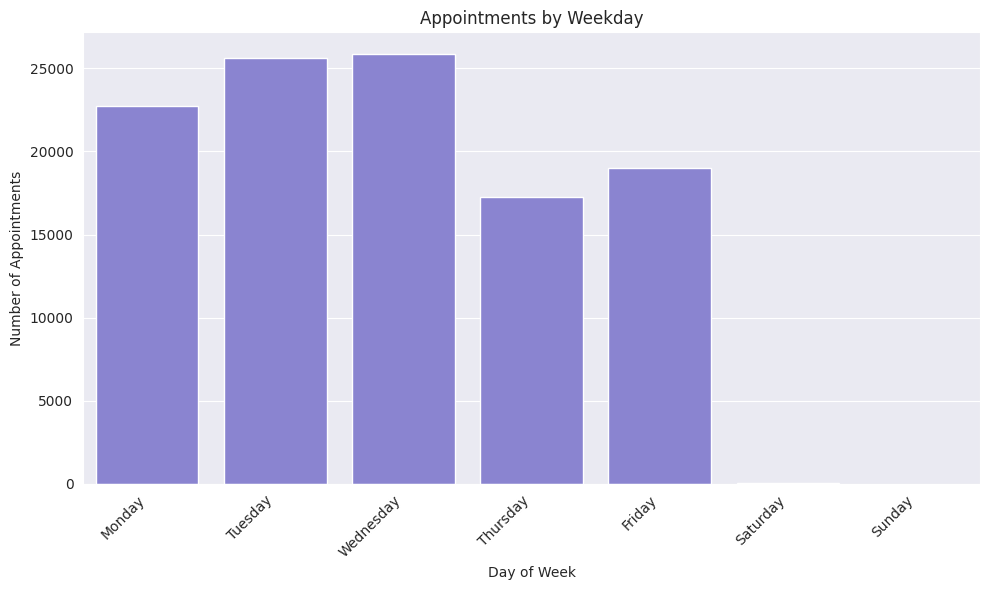

In [88]:
# Chart 5: Appointments per weekday
fig_weekday, ax_weekday = plt.subplots(1, 1, figsize=(10, 6))
sns.countplot(x='appointment_weekday_name', data=df, palette=[PURPLE], ax=ax_weekday, order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
ax_weekday.set_title('Appointments by Weekday')
ax_weekday.set_xlabel('Day of Week')
ax_weekday.set_ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

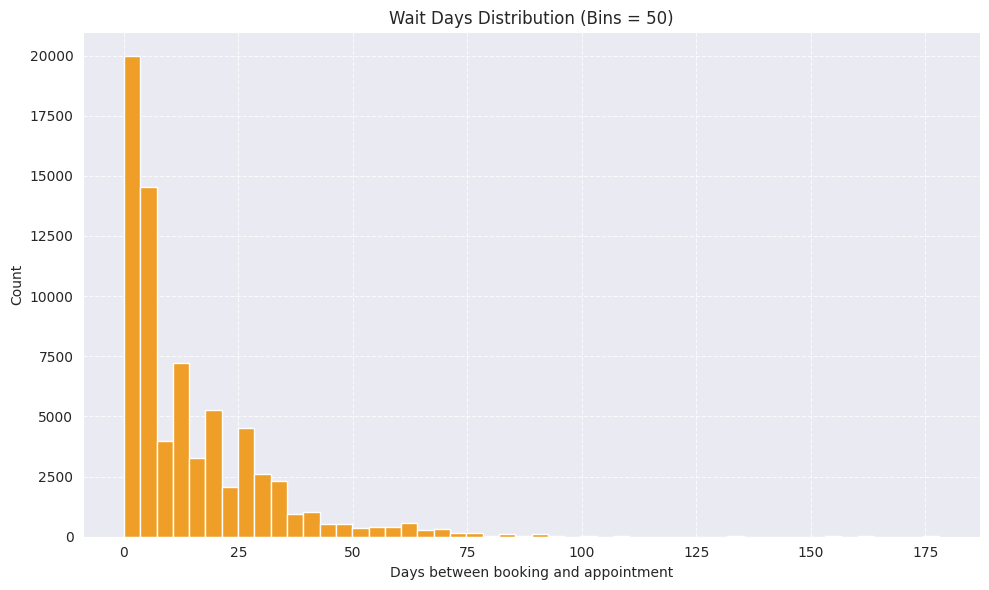

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chart 6: Wait days histogram
fig_waitdays, ax_waitdays = plt.subplots(1, 1, figsize=(10, 6))
ax_waitdays.hist(df[df['waiting_days'] >= 0]['waiting_days'], bins=50,
               color=AMBER, edgecolor='white')
ax_waitdays.set_title('Wait Days Distribution (Bins = 50)')
ax_waitdays.set_xlabel('Days between booking and appointment')
ax_waitdays.set_ylabel('Count')

# Add grid for better readability
ax_waitdays.grid(True, linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

### Explaining the 'Wait Days Distribution' Chart (50 Bins Histogram)

This chart helps us understand how long patients typically wait between scheduling their medical appointment and the actual appointment day.

*   **What the axes mean:**
    *   The **horizontal line (X-axis)** shows the number of 'Waiting Days'. This ranges from appointments scheduled on the same day (or even a day before, shown as -1) up to appointments booked many days in advance.
    *   The **vertical line (Y-axis)** indicates how many appointments fall into each of these waiting day categories.

*   **What the bars tell us:**
    *   Each bar represents a specific range of waiting days.
    *   A **tall bar** (especially near '0' on the X-axis) means many appointments are scheduled for the very near future (e.g., today or within a few days).
    *   As you move further to the right along the X-axis, if the bars become **shorter**, it means fewer appointments have very long waiting times.

*   **Key takeaway from its shape:**
    *   You'll likely observe a very high peak (or group of tall bars) near the beginning of the chart, close to the '0 days' mark. This clearly shows that a significant number of appointments are made for the immediate future.
    *   The bars then gradually decrease in height, illustrating that fewer and fewer appointments are scheduled with a long waiting period.



**NO-SHOW ANALYSIS VISUALIZATION**

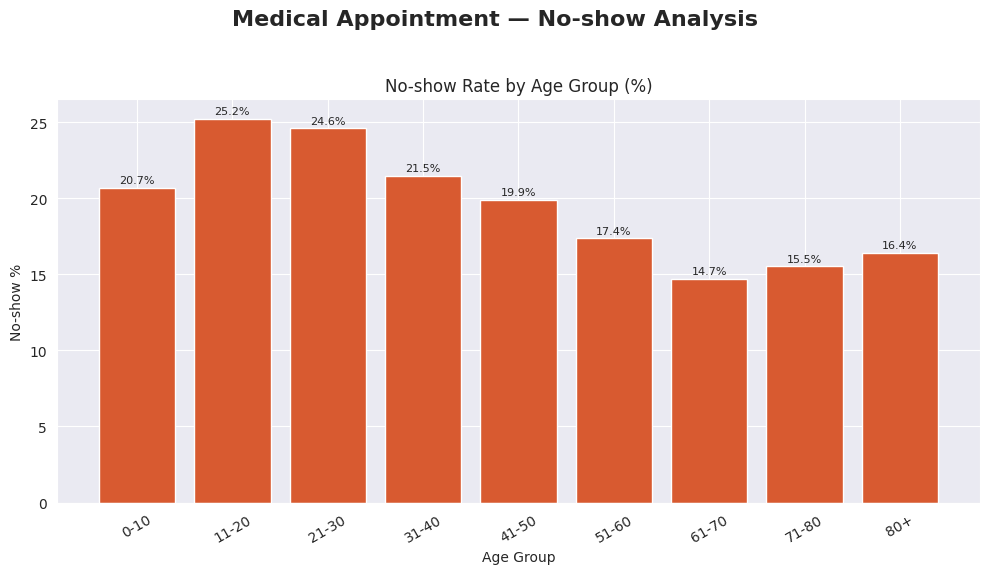

In [109]:
# NO-SHOW ANALYSIS (1 chart: No-show Rate by Age Group)
# Who is more likely to miss their appointment?

fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Create a single subplot
fig.suptitle('Medical Appointment — No-show Analysis', fontsize=16, fontweight='bold')

# Chart 1: No-show rate by age group
ag = df.groupby('AGE_GROUP', observed=True)['NO_SHOW'].mean().mul(100)
ax.bar(ag.index, ag.values, color=CORAL) # Plot on the single axis 'ax'
ax.set_title('No-show Rate by Age Group (%)')
ax.set_xlabel('Age Group')
ax.set_ylabel('No-show %')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(ag.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

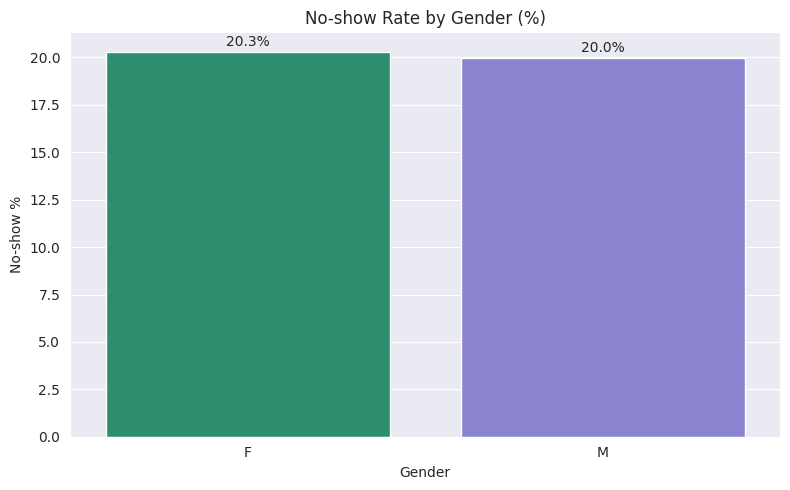

In [110]:
# ── Chart 2: No-show rate by gender ───────────────────────
gender_no_show_rate = df.groupby('GENDER')['NO_SHOW'].mean().mul(100)

fig_gender_ns, ax_gender_ns = plt.subplots(1, 1, figsize=(8, 5))
sns.barplot(x=gender_no_show_rate.index, y=gender_no_show_rate.values, palette=[TEAL, PURPLE], ax=ax_gender_ns)
ax_gender_ns.set_title('No-show Rate by Gender (%)')
ax_gender_ns.set_xlabel('Gender')
ax_gender_ns.set_ylabel('No-show %')

for i, v in enumerate(gender_no_show_rate.values):
    ax_gender_ns.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

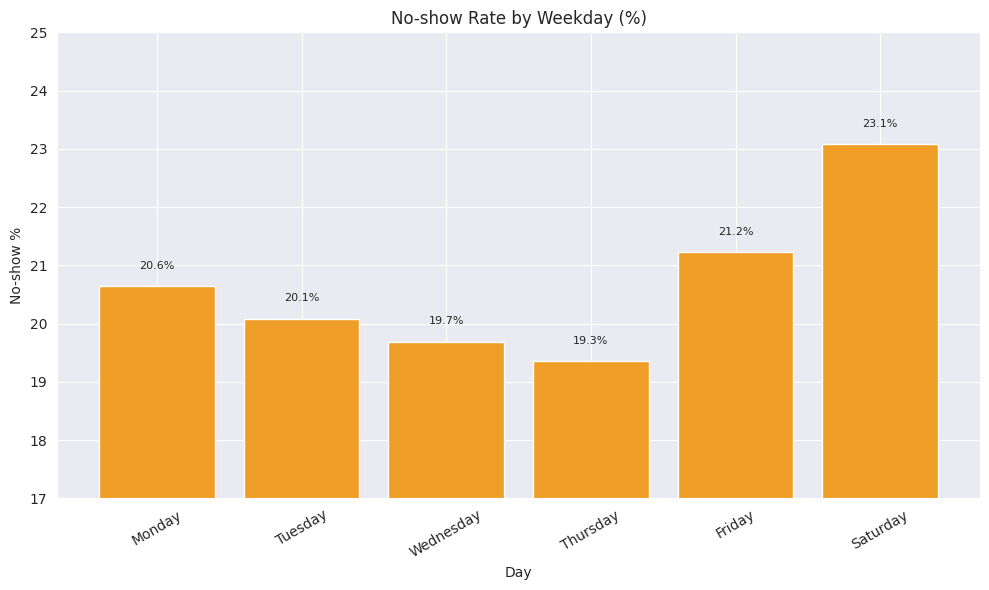

In [114]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Chart 2: No-show rate by weekday
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
dw = df.groupby('appointment_weekday_name')['NO_SHOW'].mean().mul(100).reindex(DAY_ORDER)
ax.bar(dw.index, dw.values, color=AMBER)
ax.set_title('No-show Rate by Weekday (%)')
ax.set_xlabel('Day')
ax.set_ylabel('No-show %')
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(17, 25)
for i, v in enumerate(dw.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

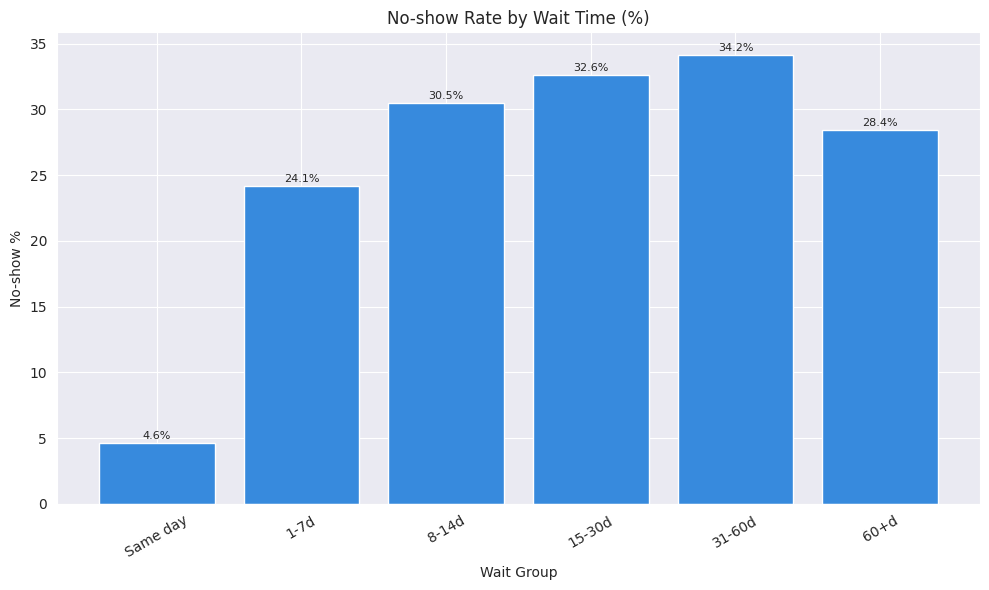

In [118]:
# ── Chart 3: No-show rate by wait time group ──────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
wg = df.groupby('WAIT_GROUP', observed=True)['NO_SHOW'].mean().mul(100)
ax.bar(wg.index, wg.values, color=BLUE)
ax.set_title('No-show Rate by Wait Time (%)')
ax.set_xlabel('Wait Group')
ax.set_ylabel('No-show %')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(wg.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

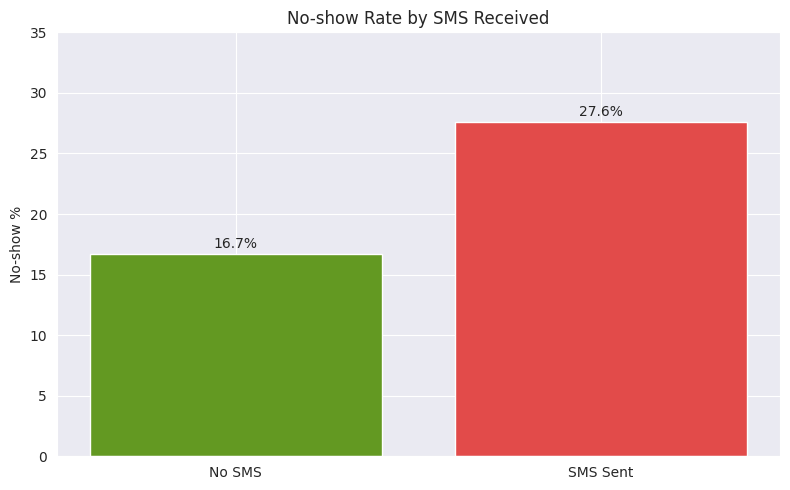

In [120]:
# Chart 4: No-show rate by SMS
fig, ax = plt.subplots(1, 1, figsize=(8, 5)) # Create a new figure and axes
sms_ns = df.groupby('SMS_RECEIVED')['NO_SHOW'].mean().mul(100).round(2)
bars = ax.bar(['No SMS', 'SMS Sent'], sms_ns.values,
                     color=[GREEN, RED])
ax.set_title('No-show Rate by SMS Received')
ax.set_ylabel('No-show %')
ax.set_ylim(0, 35)
for bar, val in zip(bars, sms_ns.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### No-show Rate by Medical Condition

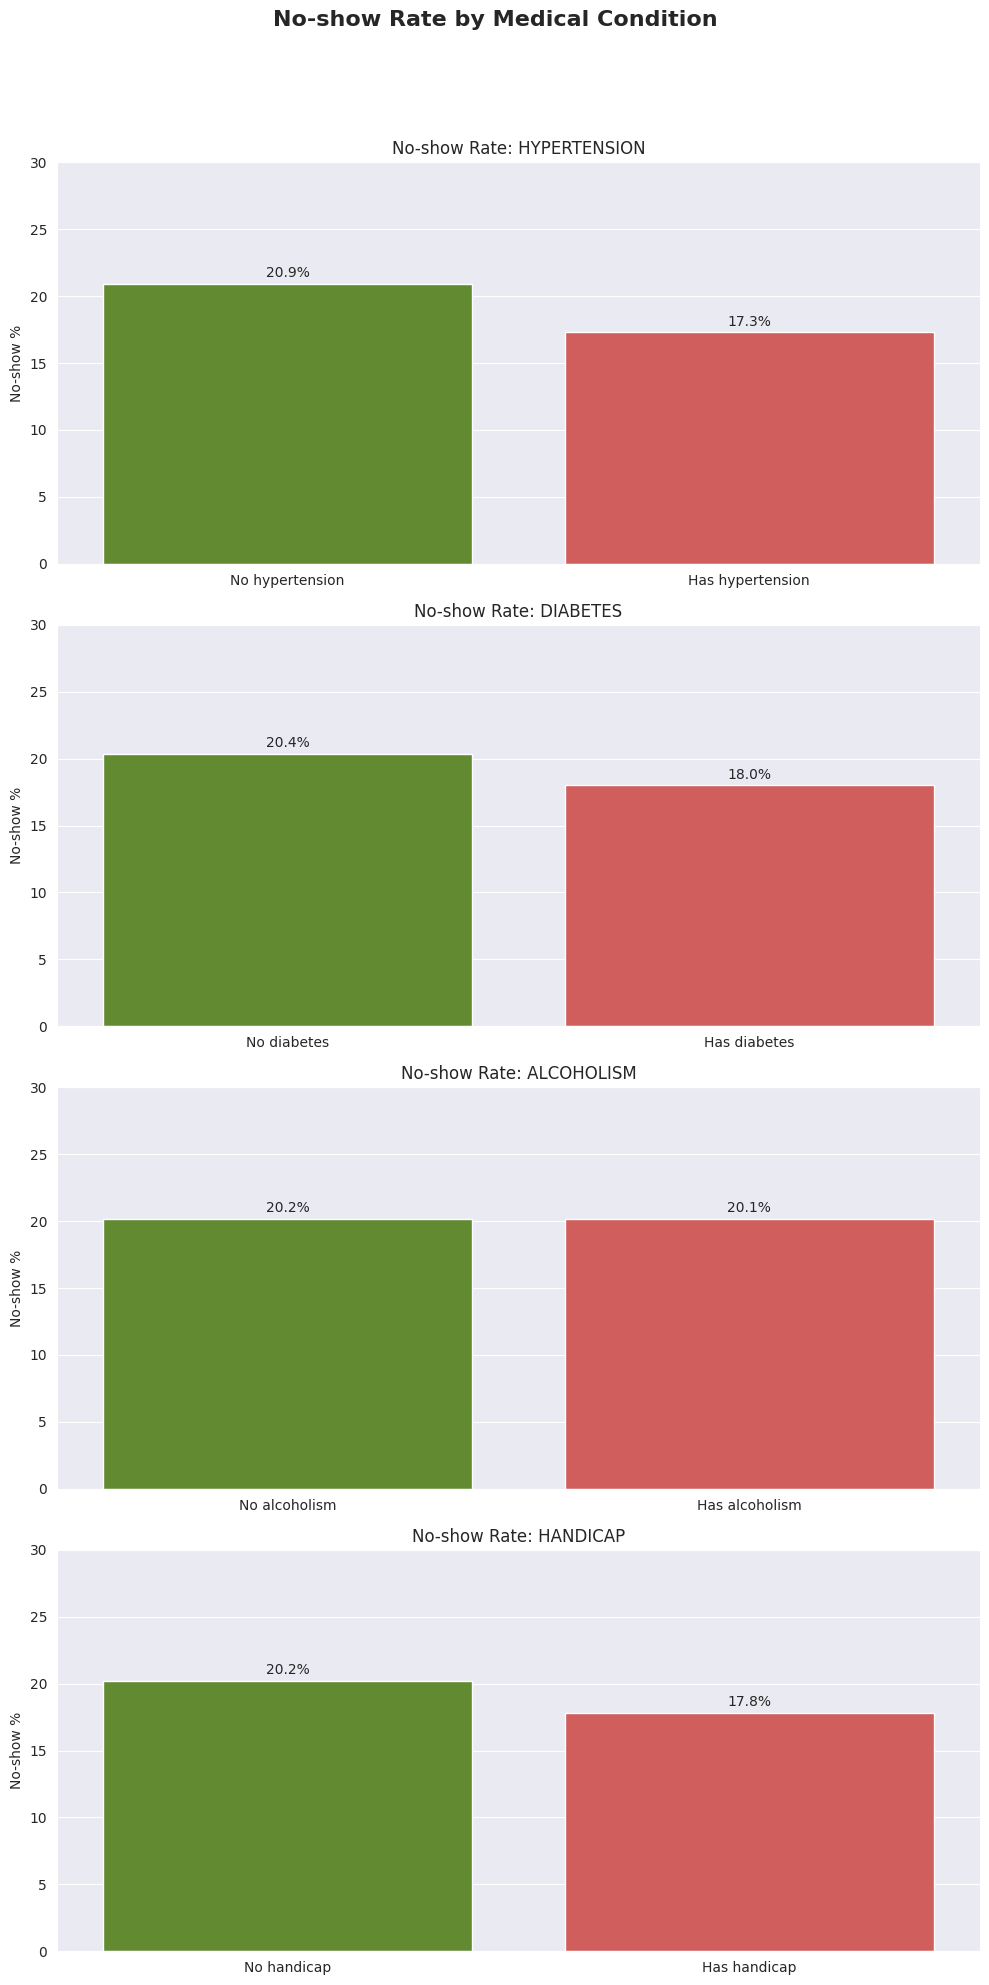

In [122]:
conditions = ['HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP']

fig, axes = plt.subplots(len(conditions), 1, figsize=(10, 5 * len(conditions)))
fig.suptitle('No-show Rate by Medical Condition', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(conditions):
    # Calculate no-show rate for patients with and without the condition
    data_for_plot = df.groupby(col)['NO_SHOW'].mean().mul(100).reset_index()
    data_for_plot[col] = data_for_plot[col].map({0: f'No {col.lower().replace("_", " ")}', 1: f'Has {col.lower().replace("_", " ")}'})

    sns.barplot(x=col, y='NO_SHOW', data=data_for_plot, palette=[GREEN, RED], ax=axes[i])
    axes[i].set_title(f'No-show Rate: {col}')
    axes[i].set_xlabel('') # Remove x-label, it's clear from the bar labels
    axes[i].set_ylabel('No-show %')
    axes[i].set_ylim(0, 30) # Set a consistent y-limit for comparison

    # Add percentages on bars
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                       f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

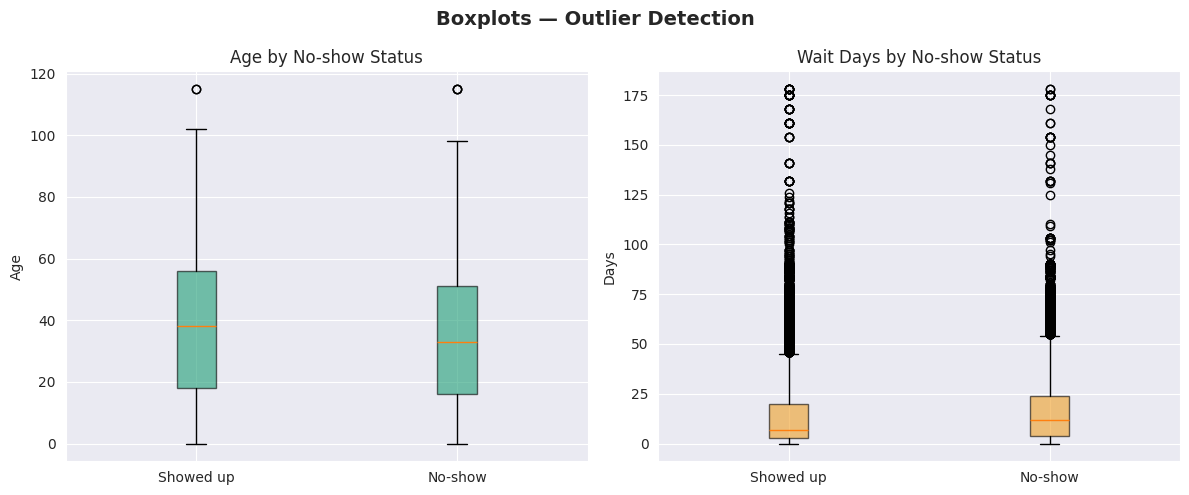

In [123]:
 #BOXPLOTS (outlier detection)
# A boxplot shows: median line, box = middle 50% of data,
# whiskers = normal range, dots beyond = outliers
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')

# ── Chart 1: Age split by no-show status ─────────────────────
# We make two separate lists: age of people who showed up vs didn't
showed = df[(df['NO_SHOW'] == 0) & (df['AGE'] >= 0)]['AGE']
noshow = df[(df['NO_SHOW'] == 1) & (df['AGE'] >= 0)]['AGE']

axes[0].boxplot([showed, noshow],
                labels=['Showed up', 'No-show'],
                patch_artist=True,          # fill the box with colour
                boxprops=dict(facecolor=TEAL, alpha=0.6))
axes[0].set_title('Age by No-show Status')
axes[0].set_ylabel('Age')

# ── Chart 2: Wait days split by no-show status ───────────────
showed_w = df[(df['NO_SHOW'] == 0) & (df['WAIT_DAYS'] >= 0)]['WAIT_DAYS']
noshow_w = df[(df['NO_SHOW'] == 1) & (df['WAIT_DAYS'] >= 0)]['WAIT_DAYS']

axes[1].boxplot([showed_w, noshow_w],
                labels=['Showed up', 'No-show'],
                patch_artist=True,
                boxprops=dict(facecolor=AMBER, alpha=0.6))
axes[1].set_title('Wait Days by No-show Status')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()

Age by No-show Status: Imagine we line up all the patients by their age, once for those who showed up and once for those who didn't. This chart shows that both groups have a similar 'middle age' (median). However, the group that didn't show up seems to have a wider range of ages, especially with some older patients missing appointments. But generally, the ages of those who show up and those who don't are pretty similar.

Wait Days by No-show Status: This is where we see a big difference! If a patient has to wait a long time between booking their appointment and the actual appointment day, they are much more likely to not show up. The chart clearly shows that people who missed their appointments generally had to wait much longer, and there's a wider spread of long waiting times among the no-show group. This suggests that the longer the wait, the higher the chance someone will forget or decide not to go.

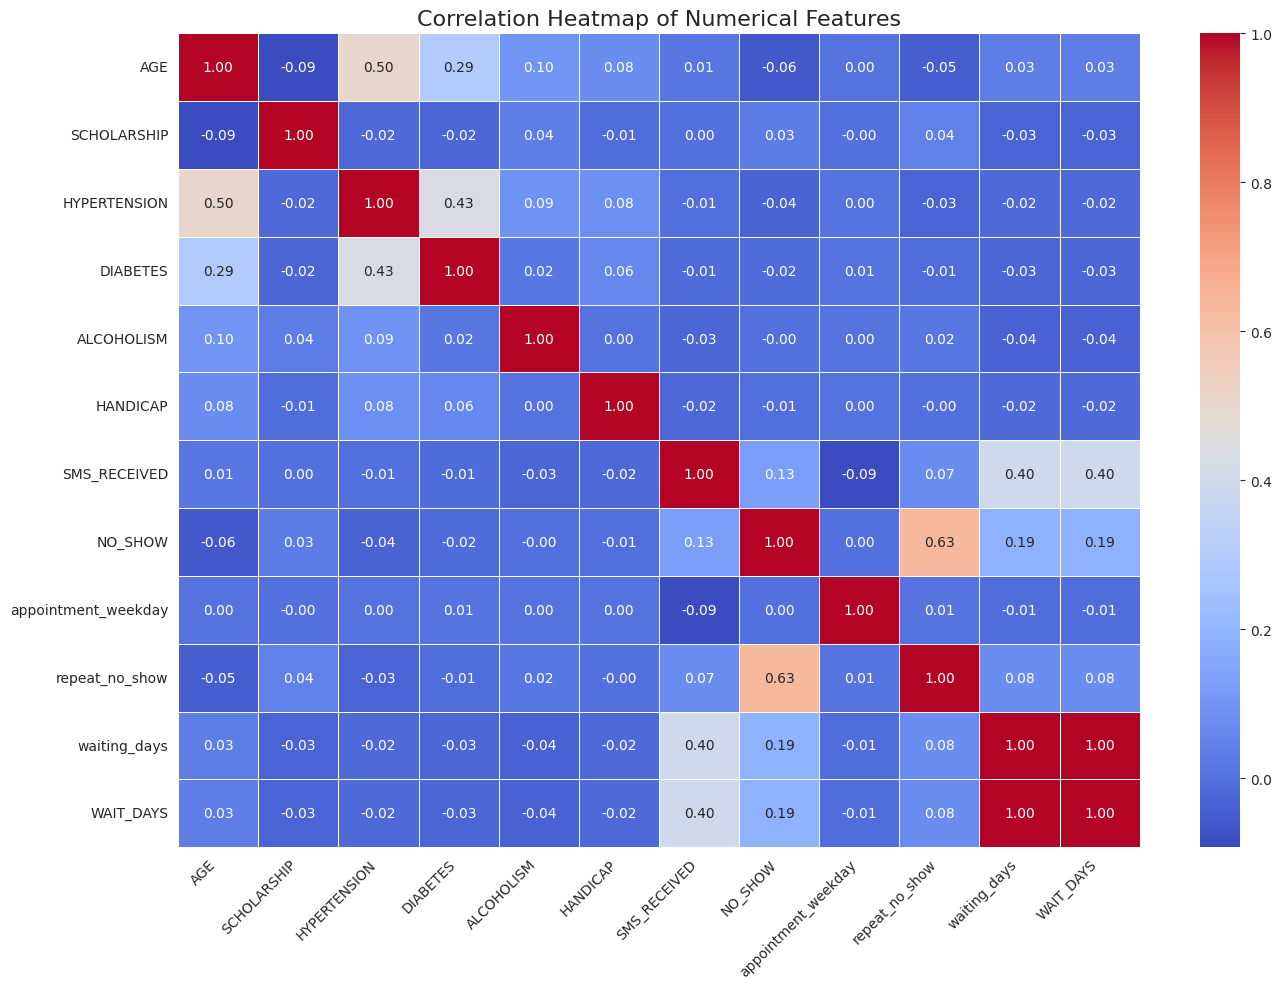

In [124]:
# CORRELATION MATRIX
# Identify numerical columns for correlation
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude ID columns if they are not truly numerical features
numerical_cols = [col for col in numerical_cols if col not in ['PATIENT_ID', 'APPOINTMENT_ID']]

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix,
            annot=True, # Show the correlation values on the heatmap
            cmap='coolwarm', # Choose a diverging colormap
            fmt='.2f', # Format annotation to two decimal places
            linewidths=.5 # Add lines between cells
           )
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Correlation Heatmap Explanation

This heatmap visualizes the Pearson correlation coefficients between all pairs of numerical variables in your dataset. The correlation coefficient ranges from -1 to +1:

*   **+1 (Dark Red/Orange):** Indicates a strong positive correlation. As one variable increases, the other tends to increase proportionally.
*   **-1 (Dark Blue):** Indicates a strong negative correlation. As one variable increases, the other tends to decrease proportionally.
*   **0 (White/Light Colors):** Indicates no linear correlation between the variables.

**How to Read It:**

*   Each square represents the correlation between the variable on its row and the variable on its column.
*   The diagonal line (from top-left to bottom-right) will always show a correlation of 1.00, as a variable is perfectly correlated with itself.
*   Look for cells with values close to +1 or -1 to identify strong relationships. For example, if 'AGE' and 'HYPERTENSION' show a high positive correlation, it suggests that older patients are more likely to have hypertension.

**TOP 5 FACTORS AFFECTING NO-SHOW**


In [126]:
# Get correlations with NO_SHOW
no_show_correlations = correlation_matrix['NO_SHOW'].drop('NO_SHOW')

# Sort by absolute value to find the strongest correlations
strongest_correlations = no_show_correlations.reindex(no_show_correlations.abs().sort_values(ascending=False).index)

print("Top 5 factors most strongly correlated with NO_SHOW:")
print(strongest_correlations.head(5))

Top 5 factors most strongly correlated with NO_SHOW:
repeat_no_show    0.629892
waiting_days      0.186320
WAIT_DAYS         0.186320
SMS_RECEIVED      0.126502
AGE              -0.060320
Name: NO_SHOW, dtype: float64


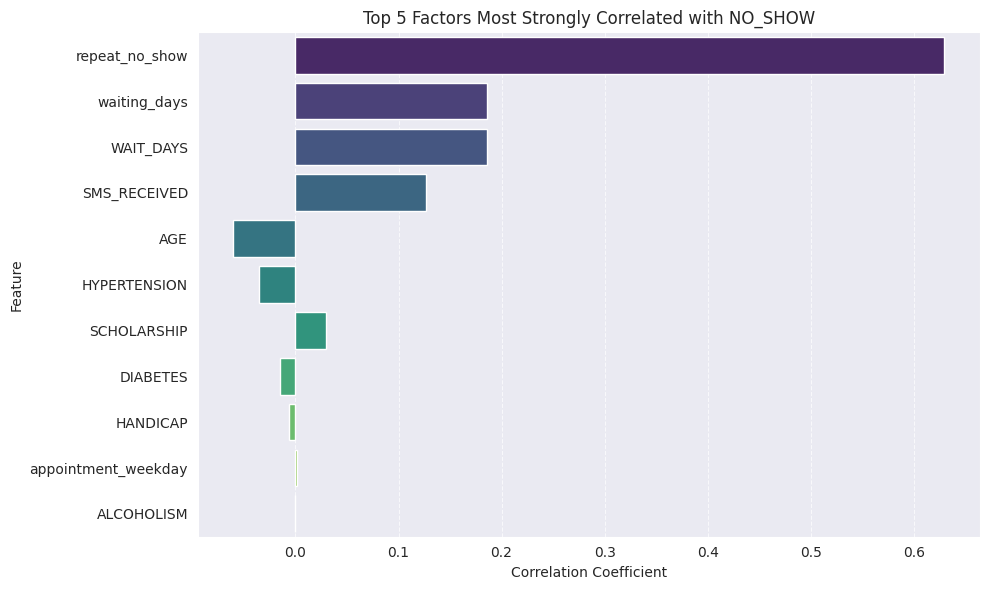

In [127]:
# Top 5 factors most strongly correlated with NO_SHOW:
plt.figure(figsize=(10, 6))
sns.barplot(x=strongest_correlations.values, y=strongest_correlations.index, palette='viridis')
plt.title('Top 5 Factors Most Strongly Correlated with NO_SHOW')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Values in Table Format

This table presents the correlation coefficients for the top 5 factors directly. It allows you to see the exact numerical strength and direction of each relationship.

In [129]:
display(strongest_correlations.to_frame(name='Correlation with NO_SHOW'))

,Correlation with NO_SHOW
repeat_no_show,0.629892
waiting_days,0.186320
WAIT_DAYS,0.186320
SMS_RECEIVED,0.126502
AGE,-0.060320
HYPERTENSION,-0.035662
SCHOLARSHIP,0.029166
DIABETES,-0.015158
HANDICAP,-0.006290
appointment_weekday,0.001189


### Top Neighborhoods by Appointment Count

This section identifies the neighborhoods with the highest number of medical appointments. Understanding where most patients come from can help in resource allocation and targeted interventions.

In [132]:
# Calculate the top 10 neighborhoods by appointment count
top_n_neighborhoods = df['NEIGHBOURHOOD'].value_counts().head(10)

print("Top 10 Neighborhoods by Appointment Count:")
print(top_n_neighborhoods.to_string())

Top 10 Neighborhoods by Appointment Count:
NEIGHBOURHOOD
Jardim Camburi       7717
Maria Ortiz          5805
Resistência          4430
Jardim Da Penha      3877
Itararé              3514
Centro               3334
Santa Martha         3131
Tabuazeiro           3131
Jesus De Nazareth    2853
Bonfim               2773


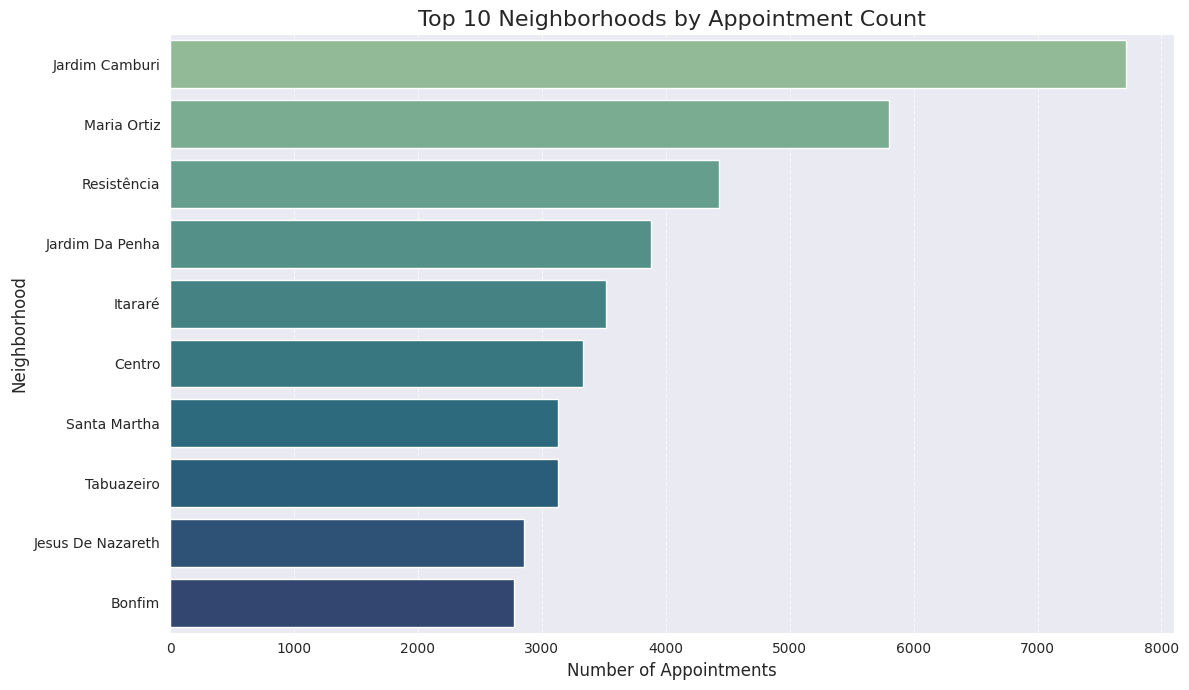

In [133]:
# Visualize the top 10 neighborhoods by appointment count
plt.figure(figsize=(12, 7))
sns.barplot(x=top_n_neighborhoods.values, y=top_n_neighborhoods.index, palette='crest')
plt.title('Top 10 Neighborhoods by Appointment Count', fontsize=16)
plt.xlabel('Number of Appointments', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [134]:
# Calculate no-show rate for each neighborhood
neighborhood_no_show = df.groupby('NEIGHBOURHOOD')['NO_SHOW'].mean().mul(100).sort_values(ascending=False)

print("Neighborhoods with Highest No-Show Rates (Top 10):")
print(neighborhood_no_show.head(10).to_string())

print("\nNeighborhoods with Lowest No-Show Rates (Bottom 10):")
print(neighborhood_no_show.tail(10).to_string())

Neighborhoods with Highest No-Show Rates (Top 10):
NEIGHBOURHOOD
Ilhas Oceânicas De Trindade    100.000000
Santos Dumont                   28.918495
Santa Cecília                   27.455357
Santa Clara                     26.482213
Itararé                         26.266363
Jesus De Nazareth               24.395373
Horto                           24.000000
Ilha Do Príncipe                23.477493
Caratoíra                       23.040936
Andorinhas                      23.032714

Neighborhoods with Lowest No-Show Rates (Bottom 10):
NEIGHBOURHOOD
Do Quadro            16.489988
Jardim Da Penha      16.275471
Santa Martha         15.841584
Do Cabral            15.714286
De Lourdes           15.409836
Solon Borges         14.712154
Mário Cypreste       14.555256
Aeroporto            12.500000
Ilha Do Boi           8.571429
Parque Industrial     0.000000


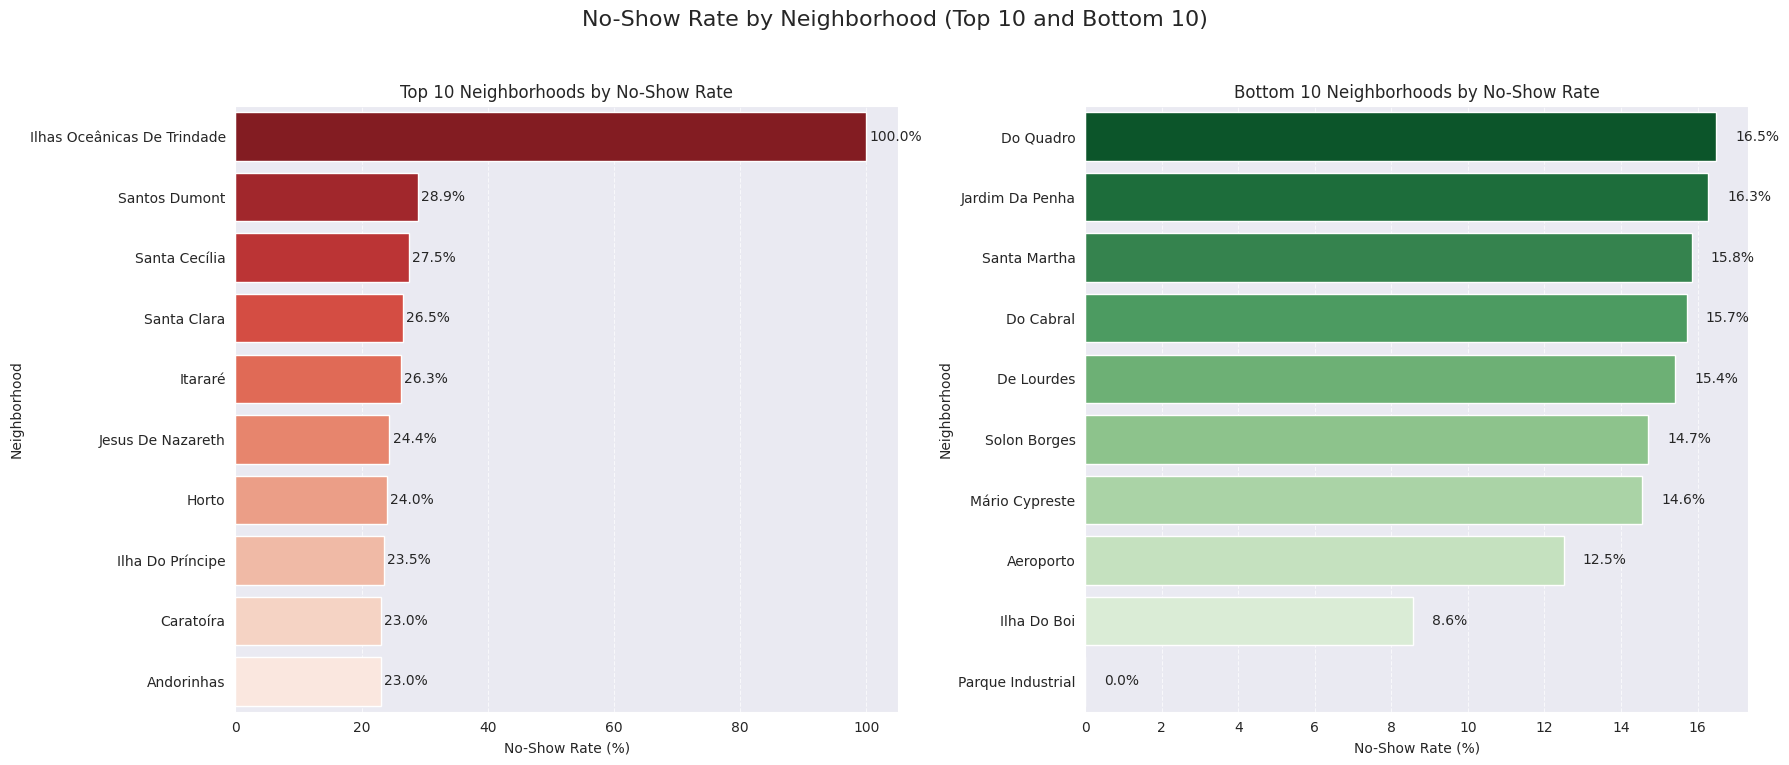

In [135]:
# Visualize no-show rates for the top 10 and bottom 10 neighborhoods

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('No-Show Rate by Neighborhood (Top 10 and Bottom 10)', fontsize=16)

# Top 10 No-Show Rates
sns.barplot(x=neighborhood_no_show.head(10).values, y=neighborhood_no_show.head(10).index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Neighborhoods by No-Show Rate')
axes[0].set_xlabel('No-Show Rate (%)')
axes[0].set_ylabel('Neighborhood')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(neighborhood_no_show.head(10).values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

# Bottom 10 No-Show Rates
sns.barplot(x=neighborhood_no_show.tail(10).values, y=neighborhood_no_show.tail(10).index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Bottom 10 Neighborhoods by No-Show Rate')
axes[1].set_xlabel('No-Show Rate (%)')
axes[1].set_ylabel('Neighborhood')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(neighborhood_no_show.tail(10).values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()